In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import yaml
import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)
from argparse import Namespace
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm 
from accelerate import Accelerator
from peft import LoraConfig, get_peft_model
from momentfm import MOMENTPipeline
from momentfm.models.statistical_classifiers import fit_svm
from collections import Counter
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
from data.interfaces.TelecomTS import TelecomTS

/home/ioannis/miniconda/envs/moment/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def control_randomness(seed: int = 77):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
class Trainer:
    def __init__(self, args, train_dataset, test_dataset):

        self.args = args
        self.train_dataset = train_dataset
        self.test_dataset = test_dataset

        x0, _, y0 = self.train_dataset[0]     
        
        if x0.ndim != 2:
            raise ValueError(f"Expected time-series with 2 dims, got shape {x0.shape}")

        n_channels = x0.shape[0]

        if hasattr(self.train_dataset, "num_classes"):
            num_class = self.train_dataset.num_classes
        elif hasattr(self.train_dataset, "n_classes"):
            num_class = self.train_dataset.n_classes
        else:
            labels = [self.train_dataset[i][2] for i in range(len(self.train_dataset))]
            num_class = len(set(int(l) for l in labels))

        self.args.n_channels = n_channels
        self.args.num_class = num_class

        print("Channels:", n_channels)
        print("Classes:", num_class)

        self.train_dataloader = DataLoader(self.train_dataset, batch_size=args.batch_size, shuffle=True)
        self.test_dataloader = DataLoader(self.test_dataset, batch_size=args.batch_size, shuffle=False)
        
        VARIANT_TO_MODEL = {
            "small": "AutonLab/MOMENT-1-small",
            "base":  "AutonLab/MOMENT-1-base",
            "large": "AutonLab/MOMENT-1-large",
        }

        VARIANT_TO_CHECKPOINT = {
            "small": "../data/checkpoints/small/TimeRAN_small.pth",
            "base": "../data/checkpoints/base/TimeRAN_base.pth",
            "large": "../data/checkpoints/large/TimeRAN_large.pth",
        }

        variant = self.args.variant.lower()
        BACKEND = self.args.backend

        if variant not in VARIANT_TO_MODEL:
            raise ValueError(f"Unknown variant '{self.args.variant}'. Choose from {list(VARIANT_TO_MODEL.keys())}")

        if BACKEND not in ["TimeRAN", "MOMENT"]:
            raise ValueError("backend must be either 'TimeRAN' or 'MOMENT'")

        MODEL_NAME = VARIANT_TO_MODEL[variant]

        self.model = MOMENTPipeline.from_pretrained(
                                                    MODEL_NAME, 
                                                    model_kwargs={
                                                        'task_name': 'classification',
                                                        'n_channels': n_channels,
                                                        'num_class': num_class,
                                                        'freeze_encoder': False if self.args.mode == 'full_finetuning' else True,
                                                        'freeze_embedder': False if self.args.mode == 'full_finetuning' else True,
                                                        'reduction': self.args.reduction,
                                                        'enable_gradient_checkpointing': False if self.args.mode in ['full_finetuning', 'linear_probing'] else True, 
                                                    }
                                                )
        
        self.model.init()

        if BACKEND == "TimeRAN":
            CHECKPOINT_PATH = VARIANT_TO_CHECKPOINT[variant]

            print(f"Loading local checkpoint: {CHECKPOINT_PATH}")
            state_dict = torch.load(CHECKPOINT_PATH, map_location="cpu")

            if any(k.startswith("module.") for k in state_dict.keys()):
                state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}

            for k in ["head.linear.weight", "head.linear.bias"]:
                state_dict.pop(k, None)

            self.model.load_state_dict(state_dict, strict=False)

        elif BACKEND == "MOMENT":
            print("Using Hugging Face pretrained MOMENT weights only")

        else:
            raise ValueError(f"Unknown backend: {BACKEND}")

        print('Model initialized, training mode: ', self.args.mode)

        self.criterion = torch.nn.CrossEntropyLoss()
        
        if self.args.mode == 'full_finetuning':
            print('Encoder and embedder are trainable')
            if self.args.lora:
                lora_config = LoraConfig(r=16, lora_alpha=32, target_modules=["q","k","v","proj"], lora_dropout=0.1)    
                self.model = get_peft_model(self.model, lora_config)
                print('LoRA enabled')
                self.model.print_trainable_parameters()

            self.optimizer = torch.optim.Adam(self.model.parameters(), lr=float(self.args.init_lr))
            self.scheduler = torch.optim.lr_scheduler.OneCycleLR(self.optimizer, max_lr=float(self.args.max_lr), 
                                                            total_steps=self.args.epochs*len(self.train_dataloader))
            
            self.accelerator = Accelerator()
            self.device = self.accelerator.device
            self.model, self.optimizer, self.train_dataloader = self.accelerator.prepare(self.model, self.optimizer, self.train_dataloader)
        
        else:
            self.optimizer = torch.optim.Adam(self.model.parameters(), lr=float(self.args.init_lr))
            self.scheduler = torch.optim.lr_scheduler.OneCycleLR(self.optimizer, max_lr=float(self.args.max_lr), 
                                                            total_steps=self.args.epochs*len(self.train_dataloader))
            self.device = f"cuda:{self.args.device}" if torch.cuda.is_available() else "cpu"


    def get_embeddings(self, dataloader: DataLoader):
        embeddings, labels = [], []

        with torch.no_grad():
            for batch_x, _, batch_labels in tqdm(dataloader, total=len(dataloader)):
                batch_x = batch_x.to(self.device).float()
                with torch.autocast(device_type='cuda', dtype=torch.bfloat16 if torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8 else torch.float32):
                    output = self.model(x_enc=batch_x, reduction=self.args.reduction) 
                embedding = output.embeddings.mean(dim=1)
                embeddings.append(embedding.detach().cpu().numpy())
                labels.append(batch_labels)        

        embeddings, labels = np.concatenate(embeddings), np.concatenate(labels)
        return embeddings, labels
    
    def get_timeseries(self, dataloader: DataLoader, agg='mean'):
        ts, labels = [], []

        with torch.no_grad():
            for batch_x, _,  batch_labels in tqdm(dataloader, total=len(dataloader)):
                if agg == 'mean':
                    batch_x = batch_x.mean(dim=1)
                    ts.append(batch_x.detach().cpu().numpy())
                elif agg == 'channel':
                    ts.append(batch_x.view(batch_x.size(0), -1).detach().cpu().numpy())
                labels.append(batch_labels)        

        ts, labels = np.concatenate(ts), np.concatenate(labels)
        return ts, labels
    
    def train(self):
        for epoch in range(self.args.epochs):

            print(f'Epoch {epoch+1}/{self.args.epochs}')
            self.epoch = epoch + 1

            if self.args.mode == 'linear_probing':
                self.train_epoch_lp()
                self.evaluate_epoch()
            
            elif self.args.mode == 'full_finetuning':
                self.train_epoch_ft()
                self.evaluate_epoch()
            
            elif self.args.mode == 'unsupervised_representation_learning':
                self.train_ul()
                break

            elif self.args.mode == 'svm':
                self.train_svm()
                break

            else:
                raise ValueError('Invalid mode, please choose svm, linear_probing, full_finetuning, or unsupervised_representation_learning')

    def train_epoch_lp(self):
        self.model.to(self.device)
        self.model.train()
        losses = []

        for batch_x, _,  batch_labels in tqdm(self.train_dataloader, total=len(self.train_dataloader)):
            self.optimizer.zero_grad()
            batch_x = batch_x.to(self.device).float()
            batch_labels = batch_labels.to(self.device)

            with torch.autocast(device_type='cuda', dtype=torch.bfloat16 if torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8 else torch.float32):
                output = self.model(x_enc=batch_x, reduction=self.args.reduction)
                loss = self.criterion(output.logits, batch_labels)
            loss.backward()

            self.optimizer.step()
            self.scheduler.step()
            losses.append(loss.item())
        
        avg_loss = np.mean(losses)
        print('Train loss: ', avg_loss)
    
    def train_epoch_ft(self):
        
        self.model.to(self.device)
        self.model.train()
        losses = []

        for batch_x, _,  batch_labels in tqdm(self.train_dataloader, total=len(self.train_dataloader)):
            self.optimizer.zero_grad()
            batch_x = batch_x.to(self.device).float()
            batch_labels = batch_labels.to(self.device)

            with torch.autocast(device_type='cuda', dtype=torch.bfloat16 if torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8 else torch.float32):
                output = self.model(x_enc=batch_x, reduction=self.args.reduction)
                loss = self.criterion(output.logits, batch_labels)
                losses.append(loss.item())
            self.accelerator.backward(loss)
            
            self.optimizer.step()
            self.scheduler.step()

        avg_loss = np.mean(losses)
        print('Train loss: ', avg_loss)
    
    def train_ul(self):
        self.model.eval()
        self.model.to(self.device)

        train_embeddings, train_labels = self.get_embeddings(self.train_dataloader)
        print('embedding shape: ', train_embeddings.shape)
        print('label shape: ', train_labels.shape)

        self.clf = fit_svm(features=train_embeddings, y=train_labels)
        train_accuracy = self.clf.score(train_embeddings, train_labels)
        print('Train accuracy: ', train_accuracy)

    def train_svm(self):
        train_embeddings, train_labels = self.get_timeseries(self.train_dataloader, agg=self.args.agg)
        self.clf = fit_svm(features=train_embeddings, y=train_labels)
        train_accuracy = self.clf.score(train_embeddings, train_labels)
        print('Train accuracy: ', train_accuracy)

    def test(self):
        if self.args.mode == 'unsupervised_representation_learning':
            test_embeddings, test_labels = self.get_embeddings(self.test_dataloader)
            test_accuracy = self.clf.score(test_embeddings, test_labels)
            print('Test accuracy: ', test_accuracy)

        elif self.args.mode == 'linear_probing' or self.args.mode == 'full_finetuning':
            self.evaluate_epoch(phase='test')

        elif self.args.mode =='svm':
            test_embeddings, test_labels = self.get_timeseries(self.test_dataloader, agg=self.args.agg)
            test_accuracy = self.clf.score(test_embeddings, test_labels)
            print('Test accuracy: ', test_accuracy)

        else:
            raise ValueError('Invalid mode, please choose linear_probing, full_finetuning, or unsupervised_representation_learning')
        
    def evaluate_epoch(self, phase='test'):
        if phase == 'test':
            dataloader = self.test_dataloader
        else:
            raise ValueError('Invalid phase, please choose val or test')

        self.model.eval()
        self.model.to(self.device)
        total_loss, total_correct = 0, 0

        all_labels = []
        all_preds = []

        with torch.no_grad():
            for batch_x, _,  batch_labels in tqdm(dataloader, total=len(dataloader)):
                batch_x = batch_x.to(self.device).float()
                batch_labels = batch_labels.to(self.device)

                with torch.autocast(
                    device_type='cuda',
                    dtype=torch.bfloat16 if torch.cuda.is_available()
                    and torch.cuda.get_device_capability()[0] >= 8
                    else torch.float32
                ):
                    output = self.model(x_enc=batch_x, reduction=self.args.reduction)
                    loss = self.criterion(output.logits, batch_labels)

                total_loss += loss.item()
                preds = output.logits.argmax(dim=1)

                total_correct += (preds == batch_labels).sum().item()

                all_labels.extend(batch_labels.cpu().numpy().tolist())
                all_preds.extend(preds.cpu().numpy().tolist())

        avg_loss = total_loss / len(dataloader)
        accuracy = total_correct / len(dataloader.dataset)

        average_type = "binary" if self.args.num_class == 2 else "macro"

        precision, recall, f1, _ = precision_recall_fscore_support(
            all_labels, all_preds, average=average_type, zero_division=0
        )

        print(
            f"[{phase.upper()}] "
            f"Loss: {avg_loss:.4f} | "
            f"Acc: {accuracy:.4f} | "
            f"Prec: {precision:.4f} | "
            f"Rec: {recall:.4f} | "
            f"F1: {f1:.4f}"
        )

        labels = list(range(self.args.num_class))
        cm = confusion_matrix(all_labels, all_preds, labels=labels)

        fig, ax = plt.subplots(figsize=(3,3))

        im = ax.imshow(cm, interpolation="nearest", cmap="Blues")

        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(
                    j, i, f"{cm[i, j]}",
                    ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black",
                    fontsize=10
                )

        ax.set_xticks(range(len(labels)))
        ax.set_yticks(range(len(labels)))
        ax.set_xticklabels(labels)
        ax.set_yticklabels(labels)

        ax.set_xlabel("Predicted", fontsize=11)
        ax.set_ylabel("True", fontsize=11)
        ax.set_title(f"{phase.capitalize()} Confusion Matrix", fontsize=12)

        ax.grid(False)

        plt.tight_layout()
        plt.show()

In [4]:
with open("config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

dataset_cfg = cfg.pop("dataset") 

args = Namespace(**cfg)  

In [5]:
control_randomness(args.seed)

In [ ]:
DATASET_REGISTRY = {
    "TelecomTS": TelecomTS
}

In [7]:
ds_class_name = dataset_cfg["class"]

if ds_class_name not in DATASET_REGISTRY:
    raise ValueError(f"Unknown dataset class: {ds_class_name}")
    
DatasetClass = DATASET_REGISTRY[ds_class_name]

In [8]:
device = f"cuda:{args.device}" if torch.cuda.is_available() else "cpu"
device

'cuda:0'

In [9]:
train_dataset = DatasetClass(data=dataset_cfg["data"], task=dataset_cfg["task"], split="train", conf=dataset_cfg)
test_dataset = DatasetClass(data=dataset_cfg["data"], task=dataset_cfg["task"], split="test", conf=dataset_cfg)

In [10]:
x0, mask0, y0 = train_dataset[0]
n_channels = x0.shape[0]                 
seq_len = x0.shape[1]                   
num_classes = len(train_dataset.class_names)  

print(f"========= {dataset_cfg['class']} Dataset Summary =========")
print(f"============== {dataset_cfg['task']['name'].capitalize()} ===============")
print(f"================ Task: {dataset_cfg['task']['target'].capitalize()} ================")

print(f"Total windows        : {len(train_dataset) + len(test_dataset)}")
print(f"Train windows        : {len(train_dataset)}")
print(f"Test windows         : {len(test_dataset)}")
print(f"Channels             : {n_channels}")
print(f"Sequence length      : {seq_len}")
print(f"Num classes          : {num_classes}")

========= TelecomTS Dataset Summary =========
============== Classification ===============
================ Task: Congestion ================
Total windows        : 1782
Train windows        : 1246
Test windows         : 536
Channels             : 16
Sequence length      : 512
Num classes          : 2


In [11]:
train_counts = Counter(train_dataset.labels)
test_counts  = Counter(test_dataset.labels)

print("\n===== Class Distribution =====")
print("Train:")
for cls_idx, count in train_counts.items():
    print(f"  {train_dataset.class_names[cls_idx]} ({cls_idx}) : {count}")

print("Test:")
for cls_idx, count in test_counts.items():
    print(f"  {test_dataset.class_names[cls_idx]} ({cls_idx}) : {count}")


===== Class Distribution =====
Train:
  0 (0) : 623
  1 (1) : 623
Test:
  1 (1) : 268
  0 (0) : 268


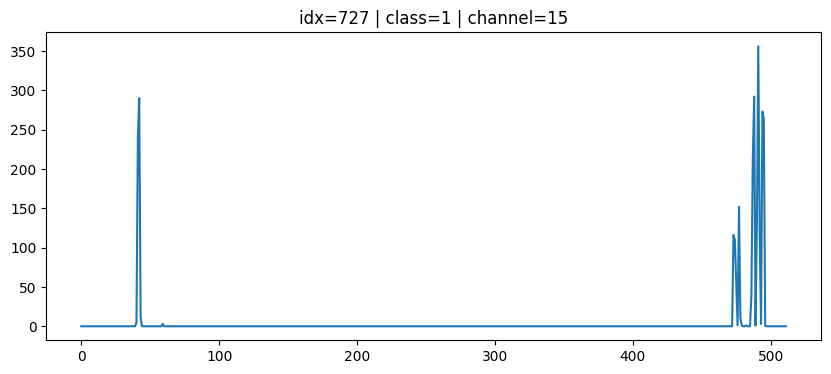

In [12]:
idx = np.random.randint(len(train_dataset))
x,mask,y = train_dataset[idx]
ch = np.random.randint(x.shape[0]) if x.shape[0] > 1 else 0
ts = x[ch].numpy()
plt.figure(figsize=(10,4))
plt.plot(ts)
plt.title(f"idx={idx} | class={train_dataset.class_names[y]} | channel={ch}")
plt.show()

Channels: 16
Classes: 2
Loading local checkpoint: ../data/checkpoints/base/TimeRAN_base.pth
Model initialized, training mode:  full_finetuning
Encoder and embedder are trainable
Epoch 1/5


100%|██████████| 39/39 [01:01<00:00,  1.57s/it]


Train loss:  0.6048997143904368


100%|██████████| 17/17 [00:09<00:00,  1.85it/s]

[TEST] Loss: 0.3351 | Acc: 0.8862 | Prec: 0.8350 | Rec: 0.9627 | F1: 0.8943


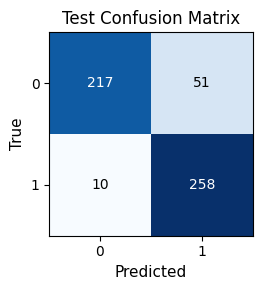

Epoch 2/5


100%|██████████| 39/39 [01:00<00:00,  1.55s/it]


Train loss:  0.17262896723472154


100%|██████████| 17/17 [00:09<00:00,  1.85it/s]

[TEST] Loss: 0.0741 | Acc: 0.9869 | Prec: 0.9815 | Rec: 0.9925 | F1: 0.9870


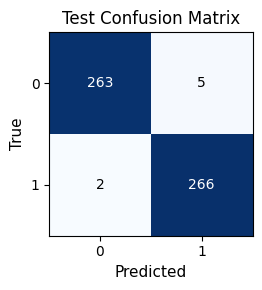

Epoch 3/5


100%|██████████| 39/39 [01:00<00:00,  1.55s/it]


Train loss:  0.035109325658338957


100%|██████████| 17/17 [00:09<00:00,  1.86it/s]

[TEST] Loss: 0.0193 | Acc: 0.9925 | Prec: 0.9853 | Rec: 1.0000 | F1: 0.9926


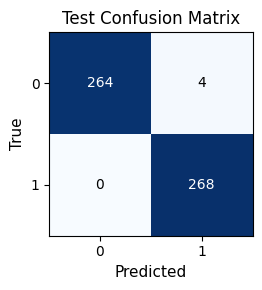

Epoch 4/5


100%|██████████| 39/39 [00:27<00:00,  1.42it/s]


Train loss:  0.008697110681961745


100%|██████████| 17/17 [00:04<00:00,  4.12it/s]


[TEST] Loss: 0.0216 | Acc: 0.9963 | Prec: 0.9926 | Rec: 1.0000 | F1: 0.9963


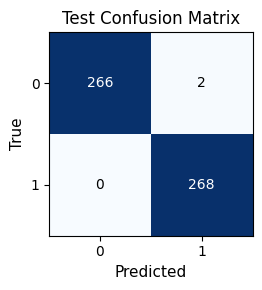

Epoch 5/5


100%|██████████| 39/39 [00:27<00:00,  1.43it/s]


Train loss:  0.005641552906196851


100%|██████████| 17/17 [00:04<00:00,  4.12it/s]


[TEST] Loss: 0.0171 | Acc: 0.9925 | Prec: 0.9853 | Rec: 1.0000 | F1: 0.9926


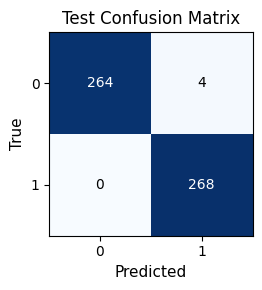

100%|██████████| 17/17 [00:03<00:00,  4.46it/s]


[TEST] Loss: 0.0171 | Acc: 0.9925 | Prec: 0.9853 | Rec: 1.0000 | F1: 0.9926


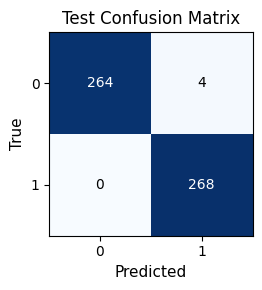

In [13]:
trainer = Trainer(args, train_dataset, test_dataset)
trainer.train()
trainer.test()